In [84]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import datetime as dt
import glob
import math
from scipy.optimize import curve_fit
from scipy import stats
import pandas as pd
import csv
import pickle
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%m-%d')

### Functions

In [3]:
def load_netcdf(filepath, in_vars):
    """ open netcdf file, load variables (in_vars should be a list) and
        output dictionary of variables"""

    out_vars = {}

    with Dataset(filepath, mode = 'r') as open_netcdf:
        if len(in_vars)>0:
            for var in in_vars:
                out_vars[var] = open_netcdf.variables[var][:]
        else:
            for var in open_netcdf.variables.keys():
                out_vars[var] = open_netcdf.variables[var][:]
    
        try:
            out_vars['time_unit'] = open_netcdf.variables['time'].units
        except:
            None

    return out_vars

In [4]:
def load_raven_sleigh_data(varnames_list):

    asfs_filepath = '/psd3data/arctic/raven_process/asfs/2_level_product/'
    asfs_lev2_files = glob.glob(asfs_filepath+'seb.level2.0.melt-sleighsfs.10min.*.nc')
    
    asfs_lev2_files.sort()

    asfs_data_lev2 = {}

    for fname in asfs_lev2_files[:]:
        # print(fname)
    
        fdic = load_netcdf(fname, varnames_list)
        fstart_time = dt.datetime.strptime(fdic['time_unit'], 'seconds since %Y-%m-%dT%H:%M:%S.000000')
        fdic['dates'] = np.asarray([fstart_time+dt.timedelta(seconds=int(m)) for m in fdic['time']])

        for var in varnames_list+['dates']:
            if var in ['base_time','time']:
                continue
            if var not in asfs_data_lev2:
                asfs_data_lev2[var] = fdic[var]
            else:
                asfs_data_lev2[var] = np.ma.concatenate( (asfs_data_lev2[var], fdic[var]), axis=0 )

    if 'down_short_hemisp' in varnames_list and 'up_short_hemisp' in varnames_list:
        asfs_data_lev2['net_short_hemisp'] = asfs_data_lev2['down_short_hemisp'] - asfs_data_lev2['up_short_hemisp']
        asfs_data_lev2['albedo'] =  asfs_data_lev2['up_short_hemisp']/asfs_data_lev2['down_short_hemisp']
        
    if 'down_short_diffuse' in varnames_list and 'down_short_direct' in varnames_list:
        asfs_data_lev2['diffuse_frac'] = asfs_data_lev2['down_short_diffuse']/asfs_data_lev2['down_short_direct']

    with np.load('/home/asledd/ICECAPS/Raven_SW-correct-tskin_emis985_all-times_20250113.npz') as npz:
        asfs_data_lev2['skin_temp'] = np.ma.MaskedArray(**npz)

    return asfs_data_lev2

In [5]:
def datetimes_to_seconds(dates_in):
    """ convert datetime objects to seconds since 1970/1/1 (arbitrary)
    dates_in should be a list or array of datetime object
    """
    seconds_out = np.asarray([(t-dt.datetime(1970,1,1)).total_seconds() for t in dates_in])
    return seconds_out

In [6]:
def interpolate_and_mask(var_data, var_secs, goal_secs):
    """
    interpolate var_data to have same time steps as goal_secs; mask data outside of bounds
    """
    var_data = np.ma.masked_invalid(var_data)
    
    f_var = interpolate.interp1d(var_secs[~var_data.mask], var_data[~var_data.mask], fill_value=-999, bounds_error=False)
    interped_var = f_var(goal_secs)
    interped_var = np.ma.masked_less(interped_var, -998)
    return interped_var

In [7]:
def round_up_to_even(f):
    if np.isnan(f):
        return np.nan
    else:
        return math.ceil(f / 2.) * 2

def round_down_to_even(f):
    return 2 * (f // 2)

In [8]:
def calc_sw_ext(sw_sfc, kappa, depths_in, f_nir=0.5):
    """ swc_sfc is net SW from the atmosphere (SWD-SWU) 
    kappa is snow extinction coefficient, which is going to be used as a tuning parameter
    f_nir is the fraction of SW that is assumed to be NIR (as opposed to visible)
    depths is assumed to be centimeters below the surface with intervals of 2cm, i.e., 2, 4, 6 etc 
    """

    ## transmitted SW at each level
    sw_t = (1-f_nir)*sw_sfc*np.ma.exp(-kappa*np.abs(depths_in))

    ## absorbed SW at each level
    sw_a = sw_t[:,:-1] - sw_t[:,1:]

    sfc_sw_a = sw_sfc[:,0]-sw_t[:,1]

    sw_a = np.concatenate((sfc_sw_a[:, np.newaxis], sw_a), axis=1)
    
    return sw_a, sw_t

In [9]:
def get_percentile_bin_vals(x_in, y_in, bins_in, p=90):
    bins_xs = []
    bins_ys = []

    for b0, b1 in zip(bins_in[:-1], bins_in[1:]):
        bin_idx = np.where((x_in>=b0)&(x_in<b1))[0]
        y_in_bin = y_in[bin_idx]

        # original version of only taking the mean/median
        bins_xs.append( np.median([b0,b1]) )
        
        if y_in_bin.shape[0]<1:
            bins_ys.append(np.nan)
            continue
            
        bin_upper_quart_val = np.percentile(y_in_bin[~y_in_bin.mask], p)
        bin_upper_quart_idx = np.ma.where(y_in_bin>=bin_upper_quart_val)
        
        bin_med = np.ma.median(y_in_bin[bin_upper_quart_idx])
        bins_ys.append(bin_med)

    
    bins_xs = np.ma.masked_invalid(bins_xs)
    bins_ys = np.ma.masked_invalid(bins_ys)
    
    return bins_xs, bins_ys

In [10]:
def get_percentile_bin_data(x_in, y_in, bins_in, p=90):
    
    for b0, b1 in zip(bins_in[:-1], bins_in[1:]):
        bin_idx = np.where((x_in>=b0)&(x_in<b1))[0]
        # get median of upper quartile

        y_in_bin = y_in[bin_idx]
        
        if y_in_bin.shape[0]<1:
            bins_ys.append(np.nan)
            continue
            
        bin_upper_quart_val = np.percentile(y_in_bin[~y_in_bin.mask], p)
        bin_upper_quart_idx = np.ma.where(y_in_bin>=bin_upper_quart_val)
        
        bin_med = np.ma.median(y_in_bin[bin_upper_quart_idx])

        y_bin_vals = y_in_bin[bin_upper_quart_idx]
        x_bin_vals = x_in[bin_idx][bin_upper_quart_idx]
        
        if b0==bins_in[0]:
            bins_xs = x_bin_vals
            bins_ys = y_bin_vals
        else:
            bins_xs = np.ma.concatenate((bins_xs, x_bin_vals))
            bins_ys = np.ma.concatenate((bins_ys, y_bin_vals))
    
    bins_xs = np.ma.masked_invalid(bins_xs).flatten()
    bins_ys = np.ma.masked_invalid(bins_ys).flatten()

    return bins_xs, bins_ys

In [11]:
def calc_ihs_temp_correct(sw_in, wspd_in, ihs_param_from_wind, fit='spline'):

    if fit=='linear':
        theta = ihs_param_from_wind['slope']*wspd_in+ihs_param_from_wind['intercept']
        temp_corrs = abs(inverse_hyperbolic_sine(sw_in, theta))
    elif fit=='spline':
        theta = ihs_param_from_wind['spline'](wspd_in)
        temp_corrs = abs(inverse_hyperbolic_sine(sw_in, theta))
    elif fit=='bin':
        temp_corrs = np.zeros(sw_in.shape)
    
        sw_mask = sw_in.mask.copy()
        sw_in[np.where(sw_in<0)] = 0
        
        for (wl, wh) in ihs_param_from_wind.keys():
            w_idx = np.where((wspd_in>=wl)&(wspd_in<wh))
            wind_temp_corrs = inverse_hyperbolic_sine(sw_in, ihs_param_from_wind[(wl, wh)])
            temp_corrs[w_idx] = wind_temp_corrs[w_idx]
    
    return temp_corrs

#### functions for different correciton curves

In [12]:
def inverse_hyperbolic_sine(x, theta):
    return np.arcsinh( x* theta)

#### main functions for calculating and applying correction

In [13]:
def get_swt_for_correction(ks, fnir, swn_in, wspd_in, skin_in):
    """ ks: extinction coefficient for visible radiation in snow
        fnir: fraction of SW that's in NIR range, as opposed to visible
        swn_in: SWN; 1D
        wspd: wind speed; 1D
    """
    
    # setup sw arrays
    dpths = np.arange(0,4.0,.02)
    dpths_2d = np.repeat(dpths[np.newaxis,:], swn_in.shape[0], axis=0)
    
    simba_swn_2d = np.repeat(swn_in[:,np.newaxis], dpths.shape[0], axis=1)
    simba_swn_2d = np.ma.masked_less(simba_swn_2d, 0)

    ## adding simba_skin in not properly just in order to see what it looks like in figure instead of depth below surface
    simba_skin_2d = np.repeat(skin_in[:,np.newaxis], dpths.shape[0], axis=1)


    simba_wspd_2d = np.repeat(wspd_in[:,np.newaxis], dpths.shape[0], axis=1)

    ## calculate transmitted SW below surface
    if isinstance(ks, float):
        ks_vis = ks
    else:
        ks_vis = np.linspace(ks[0], ks[1], simba_swn_2d.shape[0])[:,np.newaxis]
        
    sw_abs, sw_trans = calc_sw_ext(simba_swn_2d, ks_vis, dpths_2d, f_nir=fnir)
    sw_trans = np.ma.masked_array(sw_trans, mask=simba_swn_2d.mask)


    return sw_trans, simba_wspd_2d, simba_skin_2d

In [14]:
 def get_subsfc_above_zero_vals(dpths_in, swt_in, wspd2_in, sfc_in, sfc_dif, temp_in, melt_idx_in=False):
    """ melt_idx_in: indices from time series for when it is melting, such as from skin temperature or GPR
    """
    
    sfc_used = sfc_in + sfc_dif
    
    ## could rewrite this to not use a for loop, would probably look like calc_temp_corrections()
    if isinstance(melt_idx_in, bool):
        indices = range(temp_in.shape[0])
    else:
        indices = melt_idx_in

    for idx in indices:
        
        example_profile = temp_in[idx,:]
    
        idx_sfc = sfc_used[idx]
        
        subsfc_idx = np.where(simba_depths[:-1]<=idx_sfc)[0] 
        example_profile = np.squeeze(example_profile[subsfc_idx])

        too_warm_idx = np.where(example_profile>0)[0]
    
        sw_abs_warm = swt_in[idx,:][too_warm_idx]
        wspd_warm = wspd2_in[idx,:][too_warm_idx]
        temp_warm = example_profile[too_warm_idx]

        simba_skin_warm = simba_skin_2d[idx,:][too_warm_idx]
        
        ## still removing surface value
        if idx==indices[0]:
            all_subsfc_temps_above_f = temp_warm[1:]
            all_subsfc_swabs_above_f = sw_abs_warm[1:]
            all_subsfc_depths_f = abs(idx_sfc)-simba_depths[:-1][subsfc_idx][too_warm_idx][1:]

            all_subsfc_wspd_f = wspd_warm[1:]
            all_simba_skin_f = simba_skin_warm[1:]

        else:
            all_subsfc_temps_above_f = np.ma.concatenate((all_subsfc_temps_above_f, temp_warm[1:]))
            all_subsfc_swabs_above_f = np.ma.concatenate((all_subsfc_swabs_above_f, sw_abs_warm[1:]))
            all_subsfc_depths_f = np.ma.concatenate((all_subsfc_depths_f, abs(idx_sfc)-simba_depths[:-1][subsfc_idx][too_warm_idx][1:]))
            all_subsfc_wspd_f = np.ma.concatenate((all_subsfc_wspd_f, wspd_warm[:-1]))
            all_simba_skin_f = np.ma.concatenate((all_simba_skin_f, simba_skin_warm[:-1]))

    return all_subsfc_temps_above_f, all_subsfc_swabs_above_f, all_subsfc_depths_f, all_subsfc_wspd_f, all_simba_skin_f

In [77]:
def get_ihs_bin_parameters(x_data, y_data, x_bin_lims, binval='percentile', p=85):

    if binval=='max':
        bin_xs, bin_ys = get_max_bin_vals(x_data, y_data, x_bin_lims)
    elif binval=='percentile':
        bin_xs, bin_ys = get_percentile_bin_vals(x_data, y_data, x_bin_lims, p=p)
    
    ## force (0,0) point
    bin_xs = np.ma.concatenate( ([0],bin_xs) )
    bin_ys = np.ma.concatenate( ([0],bin_ys) )

    bin_xs = np.squeeze(bin_xs[~bin_ys.mask])
    bin_ys = np.squeeze(bin_ys[~bin_ys.mask])

    # IHS fit
    popt, pcov = curve_fit(inverse_hyperbolic_sine, bin_xs, bin_ys)
    
    # Extract the fitted parameter
    theta_fit = popt[0]

    return theta_fit, bin_xs, bin_ys

In [16]:
def plot_temp_swt_ihs_lines(wspd_data_dic, savepath=None):
    color_list = ['r','gold','mediumorchid','skyblue', 'yellowgreen']
    fig2, ax2 = plt.subplots(1, constrained_layout=True, figsize=(4,4))

    for i, (w_lo, w_hi) in enumerate(wspd_data_dic.keys()):

        col = plt.cm.turbo(i/len(wspd_data_dic.keys()))
        ax2.plot(wspd_data_dic[(w_lo, w_hi)]['xbin'], wspd_data_dic[(w_lo, w_hi)]['yfit'], 
                 marker='o', label='{:.0f}-{:.0f} m/s'.format(w_lo, w_hi), c=col)
    ax2.grid(alpha=.5, ls='--')
    ax2.set_xlabel('Transmitted SW [W m-2]')
    ax2.set_ylabel('Temperature [C]')
    ax2.legend(loc='best')

    if savepath:
        plt.savefig(savepath, dpi=250)
    return fig2, ax2

In [17]:
def plot_temp_swt_ihs_scatter(wspd_data_dic, savepath=None, cmap=plt.cm.viridis):
    num_axs = len(wspd_data_dic.keys())
    fig, axs = plt.subplots(1, num_axs, figsize=(1+3*num_axs,4), constrained_layout=True, sharey=True, sharex=True)

    for i, (w_lo, w_hi) in enumerate(wspd_data_dic.keys()):

        cb = axs[i].scatter(wspd_data_dic[(w_lo, w_hi)]['xdata'], wspd_data_dic[(w_lo, w_hi)]['ydata'], 
                c=wspd_data_dic[(w_lo, w_hi)]['cdata'], vmin=-20, vmax=0, cmap=cmap)
        axs[i].plot(wspd_data_dic[(w_lo, w_hi)]['xbin'], wspd_data_dic[(w_lo, w_hi)]['ybin'], c='k', marker='o')
    
        axs[i].plot(wspd_data_dic[(w_lo, w_hi)]['xbin'], wspd_data_dic[(w_lo, w_hi)]['yfit'], c='r', marker='^')    
        
        axs[i].set_title('wind speed: {:.0f}-{:.0f} m/s'.format(w_lo, w_hi))
        axs[i].grid(alpha=.5, ls='--')
        axs[i].set_xlabel('Transmitted SW [W m-2]')
        axs[i].set_ylabel('Temperature [C]')
    plt.colorbar(cb, label='Depth below surface [cm]', ax=axs[-1])
    if savepath:
        plt.savefig(savepath, dpi=250)
    return fig, axs

In [18]:
def plot_temp_corrections_wspd_curves(ihs_params_in, savepath=None):

    exmaple_sw = np.arange(0,60)

    fig, axs = plt.subplots(1,2, figsize=(8,4), constrained_layout=True, sharey=True)
    
    for wspd in range (0,18,2):
        
        # linear fit for theta parameters
        theta = ihs_params_in['slope']*wspd+ihs_params_in['intercept']  
        # print(wspd, theta)
        col = plt.cm.viridis(wspd/16.)
        axs[0].plot(exmaple_sw, np.abs(inverse_hyperbolic_sine(exmaple_sw, theta)), label='{:.0f} m/s'.format(wspd), c=col, lw=2)
    
        # spline fit for theta parameters
        theta = ihs_params_in['spline'](wspd)
        axs[1].plot(exmaple_sw, np.abs(inverse_hyperbolic_sine(exmaple_sw, theta)), label='{:.0f} m/s ({:.1f})'.format(wspd, theta), c=col, lw=2)
        
    axs[1].legend(loc='center left', bbox_to_anchor=(1,.6))
    
    for ax, fit in zip(axs.ravel(),['linear', 'spline']):
        # ax.set_ylim(0,5.5)
        ax.grid(alpha=.5, ls='--')
        ax.set_xlabel('Transmitted SW [W m-2]')
        ax.set_ylabel('Temperature correction [deg]')
        ax.set_title(fit)
        
    fig.suptitle('Inverse Hyperbolic Sine Fit')
    
    if savepath:
        plt.savefig(savepath, dpi=250)

    return fig, axs

In [19]:
def plot_ihs_param_func_of_wspd(wspds_in, ihs_vals_in, savepath=None):
    
    fig, ax = plt.subplots(1, figsize=(3,3))
    ax.scatter(wspds_in, ihs_vals_in)
    ax.grid(alpha=.5, ls='--')
    ax.set_xlabel('Median wind speed in bin [m/s]')
    ax.set_ylabel('IHS parameter')
    plt_par = np.polyfit(wspds_in, ihs_vals_in, 1, full=True)
    
    try:
        plt_t, plt_c, plt_k = interpolate.splrep(wspds_in, ihs_vals_in, k=2)
        plt_spline = interpolate.BSpline(plt_t, plt_c, plt_k, extrapolate=True)
        plt.plot(wspds_in, plt_par[0][0]*np.array(wspds_in)+plt_par[0][1], c='r')
        ax.plot(wspds_in, plt_spline(wspds_in), c='purple')
    except:
        print('incorrect wind speed bins for spline!')

    if savepath:
        plt.savefig(savepath, dpi=250)
    return fig, ax

In [76]:
def get_ihs_correction(all_subsfc_wspd_in, all_subsfc_swabs_above_in, all_subsfc_temps_above_in, \
                       all_subsfc_depths_in, ks_in, wind_ranges=[0,5,10,25], plt_figs=False, \
                       binval='max', p=85):
    max_wspd = []
    ihs_vals = []

    ihs_param_wind_regressions = {'bin':{} }
    
    bins = np.percentile(all_subsfc_swabs_above_in[~all_subsfc_swabs_above_in.mask], np.arange(0,101,5))
    
    ## added this to be able to have overlapping bins of wind speed, but that didn't make enough of an improvement to keep it
    if not isinstance(wind_ranges[0], tuple):
        loop_winds = [(wl, wh) for wl, wh in zip(wind_ranges[:-1],wind_ranges[1:])]
    else:
        loop_winds = wind_ranges

    ## save data for plotting
    temp_swt_plt_data = {(w_lo, w_hi):{} for (w_lo, w_hi) in loop_winds}
        
    for i,(w_lo, w_hi) in enumerate(loop_winds):

        w_idx = np.where((all_subsfc_wspd_in>=w_lo)&(all_subsfc_wspd_in<w_hi))
        sw_wind = all_subsfc_swabs_above_in[w_idx]
        temp_wind = all_subsfc_temps_above_in[w_idx]

        theta_fit, bin_xs, bin_ys =  get_ihs_bin_parameters(sw_wind, temp_wind, bins, binval=binval)
        
        ihs_vals.append(theta_fit)
        max_wspd.append(np.ma.median(all_subsfc_wspd_in[w_idx]))

        ihs_param_wind_regressions['bin'][(w_lo, w_hi)] = theta_fit

        # for plotting curve
        y_fit = inverse_hyperbolic_sine(bin_xs, theta_fit)

        ## save data for making plots
        temp_swt_plt_data[(w_lo, w_hi)]['xdata'] = sw_wind
        temp_swt_plt_data[(w_lo, w_hi)]['ydata'] = temp_wind
        temp_swt_plt_data[(w_lo, w_hi)]['cdata'] = all_subsfc_depths_in[w_idx]

        temp_swt_plt_data[(w_lo, w_hi)]['xbin'] = bin_xs
        temp_swt_plt_data[(w_lo, w_hi)]['ybin'] = bin_ys
        temp_swt_plt_data[(w_lo, w_hi)]['yfit'] = y_fit
    
    # save for later
    par = np.polyfit(max_wspd, ihs_vals, 1, full=True)
    ihs_param_wind_regressions['slope'] = par[0][0]
    ihs_param_wind_regressions['intercept'] = par[0][1]
    
    try:
        t, c, k = interpolate.splrep(max_wspd, ihs_vals, k=1)
        spline = interpolate.BSpline(t, c, k, extrapolate=True)
        ihs_param_wind_regressions['spline'] = spline
    except:
        ihs_param_wind_regressions['spline'] = None

    
    if plt_figs:
        fig, axs = plot_temp_swt_ihs_scatter(temp_swt_plt_data, savepath=None)
        fig2, ax2 = plot_temp_swt_ihs_lines(temp_swt_plt_data, savepath=None)
        fig3, ax3 = plot_temp_corrections_wspd_curves(ihs_param_wind_regressions, savepath=None)
        fig4, ax4 = plot_ihs_param_func_of_wspd(max_wspd, ihs_vals)
        plt.show()

    return ihs_param_wind_regressions


In [21]:
def plot_swt_corrections_contours(data_plt_dic, savepath=None):

    fig, axs = plt.subplots(2, figsize=(10,8), sharex=True, sharey=True)
    cb = axs[0].contourf(data_plt_dic['xs'], data_plt_dic['ys'], np.swapaxes(data_plt_dic['swt'],0,1), 
                         levels=np.linspace(-.01,60,11), extend='max')
    plt.colorbar(cb, label='transmitted sw [W m-2]', ax=axs[0])
    axs[0].set_ylabel('Depth from surface [m]')
    axs[0].plot(data_plt_dic['xs'], data_plt_dic['sfc'], label='interped', c='k')

    cb = axs[1].contourf(data_plt_dic['xs'], data_plt_dic['ys'], np.swapaxes(data_plt_dic['corrections'],0,1), 
                         levels=np.arange(0,5.01,.5), extend='max')
    plt.colorbar(cb, label='temperature correction [deg]', ax=axs[1])
    axs[1].set_ylabel('Depth from surface [m]')
    axs[1].plot(data_plt_dic['xs'], data_plt_dic['sfc'], label='interped', c='k')

    if savepath:
        plt.savefig(savepath, dpi=250)

    return fig, axs

In [22]:
def calc_temp_corrections(sfc_in, sfc_dif, ks, fnir, sw_in, dpths_in, correction_params, wspd_in, dates_in,\
                          plt_figs=False, param_interp='linear', swt=False, curve='ihs'):
    ## differenceing surface here!!!!
    sfc_used = sfc_in + sfc_dif
    
    # make simba heights/depths relative to surface
    depths_rel_to_sfc = np.repeat(dpths_in[np.newaxis,:], sfc_in.shape[0], axis=0)
    sfc_height_2d = np.repeat(sfc_used[:,np.newaxis], dpths_in.shape[0], axis=1)
    depths_rel_to_sfc = depths_rel_to_sfc - sfc_height_2d

    depths_rel_to_sfc = np.ma.masked_greater(depths_rel_to_sfc, 0)/100. # convert to meters
    simba_swn_2d = np.repeat(sw_in[:,np.newaxis], depths_rel_to_sfc.shape[1], axis=1)

    if isinstance(ks, float):
        ks_vis = ks
    else:
        # if you want the extinction coefficient to change linearly over time
        ks_vis = np.linspace(ks[0], ks[1], simba_swn_2d.shape[0])[:,np.newaxis]
        
    simba_swa, simba_swt = calc_sw_ext(simba_swn_2d, ks_vis, depths_rel_to_sfc, f_nir=fnir)
    simba_swt = np.ma.masked_array(simba_swt, mask=depths_rel_to_sfc.mask) # mask levels above surface that aren't relevant
    
    wspd_2d_full = np.repeat(wspd_in[:,np.newaxis], simba_swn_2d.shape[1], axis=1)
    wspd_2d_full = np.ma.masked_array(wspd_2d_full, mask=depths_rel_to_sfc.mask)

    if param_interp=='bin':
        temp_correction = calc_ihs_temp_correct(simba_swt, wspd_2d_full, correction_params['bin'], fit=param_interp)
    else:    
        temp_correction = calc_ihs_temp_correct(simba_swt, wspd_2d_full, correction_params, fit=param_interp)

    if plt_figs:
        plting_data = {'xs':dates_in, 'ys':dpths_in, 'swt':simba_swt, 'corrections':temp_correction, 'sfc':sfc_used}
        fig, axs = plot_swt_corrections_contours(plting_data)
        plt.show()

    if swt:
        return temp_correction, simba_swt
    else:
        return temp_correction

In [23]:
def plot_un_and_corrected_sfc_temps(uncorrect_simba, correct_simba, sleigh_skin_in, plt_dates, summ_dates_in, savepath=None):
    
    fig, ax = plt.subplots(1,figsize=(10,6))
    plt.scatter(plt_dates, uncorrect_simba, label='UNcorrected simba', lw=1, ls='--', c='tab:blue', s=20)

    plt.scatter(plt_dates, correct_simba, label='corrected simba', lw=1,  c='tab:orange', s=20)
    plt.scatter(plt_dates, sleigh_skin_in, label='SLEIGH skin', c='k', s=20)

    plt.legend(loc='best')
    plt.grid()
    plt.xlim(summ_dates_in)
    
    if savepath:
        plt.savefig(savepath, dpi=250)
    return fig, ax

In [24]:
def get_sfc_data(data_in, depths_1d, sfc_1d):
    
    sfc_repeat = np.repeat(sfc_1d[:,np.newaxis], depths_1d.shape[0], axis=1)
    heights_repeat = np.repeat(depths_1d[np.newaxis,:], data_in.shape[0], axis=0)

    if len(data_in.shape)<2:
        data_2d = np.repeat(data_in[:,np.newaxis], depths_1d.shape[0], axis=1)
    else:
        data_2d = data_in
    sfc_data = data_2d[np.where(heights_repeat==sfc_repeat)]
        
    return sfc_data

In [25]:
def plot_sleigh_skin_vs_simba_sfc_scatter(correct_simba, sleigh_skin_in, color_var, savepath=None):
    fig, ax = plt.subplots(1)
    
    cb = plt.scatter(sleigh_skin_in, correct_simba, c=color_var)
    plt.colorbar(cb, label='SWT [W m-2]')
    plt.ylabel('Corrected SIMBA sfc temperature [C]')
    plt.xlabel('SLEIGH skin temperature [C]')
    plt.plot([sleigh_skin_in.min(), sleigh_skin_in.max()], 
             [sleigh_skin_in.min(), sleigh_skin_in.max()], c='k')
    plt.grid(alpha=.5, ls='--')
    
    if savepath:
        plt.savefig(savepath, dpi=250)
    return fig, ax

In [26]:
def plot_un_corrected_summary(uncorrect_simba, correct_simba, plt_dates, summ_dates_in, \
                              skin_t_simba_steps_in, uncorrect_simba_sfc, correct_simba_sfc, 
                              skin_t_sleigh_steps_in, simba_secs, sfc_in, depths_in, 
                              d, m, savepath=None):
    
    output_summary = {'ts_diff_mean':{},'ts_diff_min':{},'ts_diff_max':{}, 'above_zero_count':{}, 'above_0.5_count':{}}
    
    fig = plt.figure(figsize=(7,7), constrained_layout=True)
    
    ax1 = plt.subplot2grid(shape=(2,2), loc=(0, 0), colspan=1)
    ax2 = plt.subplot2grid((2,2), (1, 0))
    ax3 = plt.subplot2grid(shape=(2,2), loc=(0, 1), rowspan=2)
    
    axs = [ax1, ax2, ax3]

    corrected_temps = correct_simba.copy()
    
    uncorrected_temps = np.ma.masked_array(uncorrect_simba, mask=corrected_temps.mask)

    ## default is all summary included
    second_dummy_dates = np.ma.repeat(plt_dates[:,np.newaxis], uncorrected_temps.shape[1], axis=1)
    second_dummy_dates = np.ma.masked_outside(second_dummy_dates, summ_dates_in[0], summ_dates_in[1])

    uncorrected_temps = np.ma.masked_array(uncorrected_temps, mask=second_dummy_dates.mask)
    corrected_temps = np.ma.masked_array(corrected_temps, mask=second_dummy_dates.mask)

    uncorrected_temps_positive = np.ma.masked_less(uncorrected_temps,0)
    corrected_temps_positive = np.ma.masked_less(corrected_temps, 0)
    
    uncorrected_temps_positive_uncert = np.ma.masked_less(uncorrected_temps,0.5)
    corrected_temps_positive_uncert = np.ma.masked_less(corrected_temps,0.5)
    
    for simba_var, label in zip([uncorrected_temps_positive_uncert, corrected_temps_positive_uncert], ['uncorrected','corrected']):
        output_summary['above_0.5_count'][label] = simba_var.count()

    bins = np.arange(0,8.01,.5)
    for simba_var, label in zip([uncorrected_temps_positive, corrected_temps_positive], ['uncorrected','corrected']):

        axs[0].hist(simba_var[~simba_var.mask], alpha=.6, 
                label=label+' (total: {:.0f})'.format(simba_var.count()), bins=bins)
        output_summary['above_zero_count'][label] = simba_var.count()

    axs[0].set_ylabel('Counts')
    axs[0].set_xlabel('Temperature>0 below surface [deg]')
    axs[0].legend(loc='best')


    for simba_var, label in zip([uncorrect_simba_sfc, correct_simba_sfc], ['uncorrected','corrected']):
        sfc_temp_diff = simba_var - skin_t_simba_steps_in
        output_summary['ts_diff_mean'][label] = np.nanmean(sfc_temp_diff)
        axs[1].hist(sfc_temp_diff[~sfc_temp_diff.mask].flatten(), alpha=.6, 
                    label=label+' (mean: {:.1f})'.format(output_summary['ts_diff_mean'][label]),
                    bins=np.arange(-8,10,.5))
    
    axs[1].axvline(x=0, c='k', lw=1)
    axs[1].set_xlabel('SIMBA sfc -SLEIGH skin [deg]')
    axs[1].set_ylabel('Counts')
    axs[1].legend(loc='best')

    sleigh_tskin_profile_comparison_steps = skin_t_sleigh_steps_in - 273.15

    ## other good days to check: 717-7/21; originially 7/11 
    for temp_data, c in zip([uncorrected_temps, corrected_temps], ['tab:blue','tab:orange']):
        st_date = dt.datetime(2024, m, d, 6)
        en_date = dt.datetime(2024, m, d, 16)
        figure_date_idx = np.where((np.asarray(plt_dates)>=st_date )&(np.asarray(plt_dates)<en_date ))[0]
    
        for i, t_idx in np.ndenumerate(figure_date_idx[1:]):
            axs[2].plot(np.squeeze(temp_data[t_idx, :-1]), depths_in[:-1], label=t_idx, c=c)#'t=0')
            
            if c=='tab:orange':
                if not np.ma.is_masked(sfc_in[t_idx]):
                    axs[2].scatter(np.squeeze(sleigh_tskin_profile_comparison_steps[t_idx]), 
                                   np.squeeze(sfc_in[t_idx]), c='gray')
    
    axs[2].set_xlabel('Temperature [deg]')
    axs[2].set_ylabel('Depth [cm]')
    axs[2].set_title(st_date.strftime('%Y-%m-%d %H:%M')+'-'+en_date.strftime('%H:%M'))
    axs[2].axvline(x=0, c='k', lw=1)
    axs[2].axvline(x=0.5, c='k', lw=1, ls='--')
    axs[2].axvline(x=1.5, c='k', lw=1, ls='--')

    for ax in axs:
        ax.grid(ls='--', alpha=.5)

    
    if savepath:
        plt.savefig(savepath, dpi=250)
    return fig, axs

In [27]:
def correct_compare_temp(temp_corrects, sfc_in, sfc_dif, ks, fnir, simba_temps_in, simba_dpths_in, dates_in, skinT_in, fpath, \
                         out_correct_t=True, swi=False, d=11, m=7, summ_dates=(dt.datetime(2024,5,20), dt.datetime(2024,7,26))):
    sfc_used = sfc_in + sfc_dif

    sfc_repeat = np.repeat(sfc_used[:,np.newaxis], simba_temps_in.shape[1], axis=1)
    heights_repeat = np.repeat(simba_dpths_in[np.newaxis,:], simba_temps_in.shape[0], axis=0)

    seconds_in = datetimes_to_seconds(dates_in)
    sfc_seconds = get_sfc_data(seconds_in, simba_dpths_in, sfc_used)
    sfc_dates = get_sfc_data(dates_in, simba_dpths_in, sfc_used)
    
    corrected_temps = simba_temps_in - temp_corrects
    corrected_temps = np.ma.masked_where(heights_repeat>sfc_repeat, corrected_temps)

    sleigh_skinT_simba_timesteps = interpolate_and_mask(skinT_in, seconds_in, sfc_seconds)
    sleigh_skinT_simba_timesteps -= 273.15

    uncorrected_simba_sfc_temp = get_sfc_data(simba_temps_in, simba_dpths_in, sfc_used)
    corrected_simba_sfc_temp = get_sfc_data(corrected_temps, simba_dpths_in, sfc_used)
    
    ## default is all summary included
    fig_dates = np.ma.copy(sfc_dates)
    fig_dates = np.ma.masked_outside(fig_dates, summ_dates[0], summ_dates[1])

    uncorrected_simba_sfc_temp = np.ma.masked_array(uncorrected_simba_sfc_temp, mask=fig_dates.mask)
    corrected_simba_sfc_temp = np.ma.masked_array(corrected_simba_sfc_temp, mask=fig_dates.mask)

    ## timeseries of temperatures
    fig, ax = plot_un_and_corrected_sfc_temps(uncorrected_simba_sfc_temp, corrected_simba_sfc_temp, \
                                              sleigh_skinT_simba_timesteps, fig_dates, summ_dates)
    plt.show()

    if not isinstance(swi, bool):
        fig, ax = plot_sleigh_skin_vs_simba_sfc_scatter(corrected_simba_sfc_temp, sleigh_skinT_simba_timesteps,\
                                                        swi[np.where(heights_repeat==sfc_repeat)])
        plt.show()
        
    ## summary figures here
    ## for comparisons
    fig, axs = plot_un_corrected_summary(simba_temps_in, corrected_temps, dates_in, summ_dates, sleigh_skinT_simba_timesteps, \
                                         uncorrected_simba_sfc_temp, corrected_simba_sfc_temp, skinT_in, \
                                         seconds_in, sfc_used, simba_dpths_in, d, m)
    plt.show()
    return corrected_temps

### opening data

In [29]:
# SIMBA temperature profiles
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
simba_fname = 'firnprofile_solar-shading-corrected.nc'

season_data = {}
varnames = ['temperature','initial_height','shading_correction','time']
season_data = load_netcdf(simba_filepath+simba_fname, varnames)

fstart_time = dt.datetime.strptime(season_data['time_unit'], 'seconds since %Y-%m-%d %H:%M')

season_data['dates'] = np.asarray([fstart_time+dt.timedelta(seconds=int(m)) for m in season_data['time']])

# need to have heights/depth decrease, as in the first index is the top of the SIMBA
## unclear if I still need this?
season_data['initial_height'] = season_data['initial_height'][::-1]
season_data['temperature'] = season_data['temperature'][:,::-1]

In [228]:
season_data['shading_correction'] = season_data['shading_correction'][:,::-1]

In [115]:
# snow-atmosphere interface from SIMBA
sfc_fname = 'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_dble-splice_v1.csv' # max_var_sfcs['dTdz'][24*4]
sfc_save_fpath = '/home/asledd/ICECAPS/double_splice_sfcs/'

df = pd.read_csv(sfc_save_fpath+sfc_fname)
simba_sfc_dates = np.array([dt.datetime.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['datetime'].values])       
simba_sfc_in = df['surface [cm]'].values

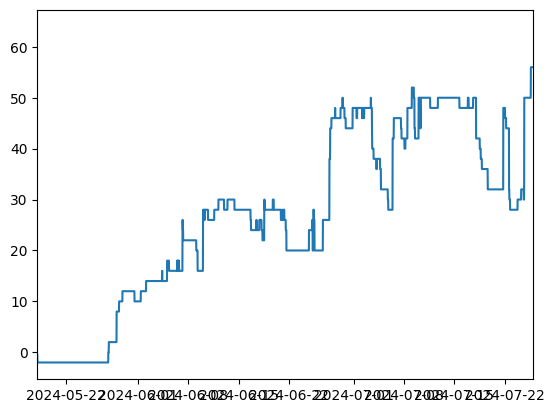

In [116]:
plt.plot(simba_sfc_dates, simba_sfc_in)
plt.xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,26))
plt.show()

In [117]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc',
               'skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                'snow_depth','temp','brightness_temp_surface','skin_temp_surface','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

In [32]:
data = np.genfromtxt('/home/asledd/ICECAPS/preliminary_raven_winds_icecaps_2024May20th_2024July23rd.csv', delimiter=',',
                         usecols=(0,5), dtype=None, encoding='utf-8')
raw_wind_spd = np.array(data[1:,1])
raw_wind_spd[np.where(raw_wind_spd=='')] = -999
raw_wind_spd = raw_wind_spd.astype(np.float32)

raw_wind_dates = np.asarray([dt.datetime.strptime(d, '%Y-%m-%d %H:%M:%S') for d in data[1:,0]])


## It's annoying to have the winds with different time steps, make it match the sleigh dates
wind_spd = []

for date in asfs_data_lev2['dates']:
    
    if date in raw_wind_dates:
        wind_spd.append(raw_wind_spd[np.where(date==raw_wind_dates)[0]][0])
    else:
        wind_spd.append(-999)

wind_spd_all = np.ma.masked_equal(wind_spd, -999)

### set up variables for use

Largely getting everything to have same time steps

In [118]:
simba_depths = season_data['initial_height']
simba_dates_all = season_data['dates']
sleigh_dates_all = asfs_data_lev2['dates']

sleigh_seconds_all = datetimes_to_seconds(sleigh_dates_all)
simba_seconds_all = datetimes_to_seconds(simba_dates_all)

simba_temps_all = season_data['temperature']
swn_all = asfs_data_lev2['net_short_hemisp']
sleigh_skin_all = asfs_data_lev2['skin_temp'] # this variable is the skin temperature using LW fluxes corrected for their own solar bias

In [119]:
## interpolate simba_sfc to have same timesteps as rest of simba data
sfc_seconds_all = datetimes_to_seconds(simba_sfc_dates)
simba_sfc_all = interpolate_and_mask(simba_sfc_in, sfc_seconds_all, simba_seconds_all)

## need to round because SIMBA has 2 cm resolution
simba_sfc_all = round_down_to_even(np.squeeze(simba_sfc_all))

In [120]:
## get same time intervals
sleigh_idx = np.where((sleigh_dates_all>dt.datetime(2024,5,20))&(sleigh_dates_all<dt.datetime(2024,7,24)))[0]
imb_idx = np.where((simba_dates_all>dt.datetime(2024,5,20))&(simba_dates_all<dt.datetime(2024,7,24)))[0]

In [121]:
simba_dates = simba_dates_all.copy()[imb_idx]
simba_temps = simba_temps_all.copy()[imb_idx,:]
simba_sfc = simba_sfc_all.copy()[imb_idx]

sleigh_dates = sleigh_dates_all.copy()[sleigh_idx]

sleigh_seconds = sleigh_seconds_all.copy()[sleigh_idx]
simba_seconds = simba_seconds_all.copy()[imb_idx]

swn = swn_all.copy()[sleigh_idx]
wind_spd = wind_spd_all.copy()[sleigh_idx]
sleigh_skin = sleigh_skin_all.copy()[sleigh_idx]

In [122]:
simba_swn = interpolate_and_mask(swn[~swn.mask], sleigh_seconds[~swn.mask], simba_seconds)
simba_wspd = interpolate_and_mask(wind_spd[~wind_spd.mask], sleigh_seconds[~wind_spd.mask], simba_seconds)
simba_skin = interpolate_and_mask(sleigh_skin[~sleigh_skin.mask], sleigh_seconds[~sleigh_skin.mask], simba_seconds)



In [123]:
simba_dates_2d = np.ma.repeat(simba_dates[:,np.newaxis], simba_temps.shape[1], axis=1)

In [225]:
ks_i = 19. # visible extinction coefficient for exponential decay of SW that gets transmitted below first layer
fnir_i = 0.5 # fraction of NIR radiation that gets absorbed in top layer of snow
sfc_dif_i = 4. # offset applied to entire surface time series in cm

In [215]:
multi_adjusted_sfc = simba_sfc.copy()
multi_adjusted_sfc[np.where(simba_dates<dt.datetime(2024,6,5))] += 4
multi_adjusted_sfc[np.where(simba_dates>=dt.datetime(2024,6,5))] += 4

The correction is determined for the upper 85th percentile of data because the temperature above 0C is the *minimum* amount that the temperatures must be biased. We're assuming that the greatest tempeatures above 0C for any given SWT value are actually melting and that the degrees above 0C are the actual bias.

In [200]:
masked_simba_temp = np.ma.masked_where((simba_dates_2d>dt.datetime(2024,7,17,12))&(simba_dates_2d<dt.datetime(2024,7,18)), simba_temps)
masked_simba_temp = np.ma.masked_where((simba_dates_2d>dt.datetime(2024,6,11,10))&(simba_dates_2d<dt.datetime(2024,6,12)), masked_simba_temp)
masked_simba_temp = np.ma.masked_where((simba_dates_2d>dt.datetime(2024,6,17,12))&(simba_dates_2d<dt.datetime(2024,6,18)), masked_simba_temp)

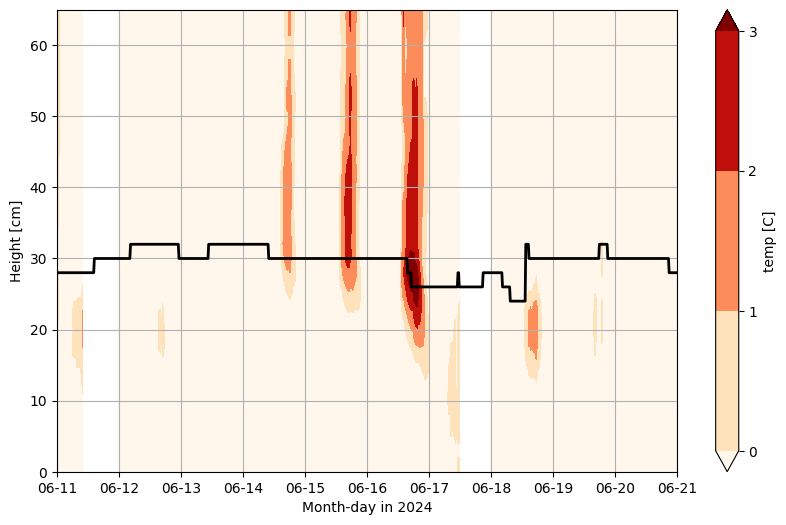

In [201]:
fig, ax = plt.subplots(1, figsize=(10,6))

cb = plt.contourf(simba_dates, simba_depths, np.swapaxes(masked_simba_temp,0,1), levels=np.arange(0,4,1), 
                  cmap=plt.cm.OrRd, extend='both')
plt.colorbar(cb, label='temp [C]')
plt.plot(simba_dates, multi_adjusted_sfc, c='k', lw=2)
ax.set_xlim(dt.datetime(2024,6,11),dt.datetime(2024,6,21))
# ax.set_xlim(dt.datetime(2024,5,21),dt.datetime(2024,6,1))

ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
plt.ylabel('Height [cm]')
plt.grid()
plt.ylim(0,65)
plt.show()

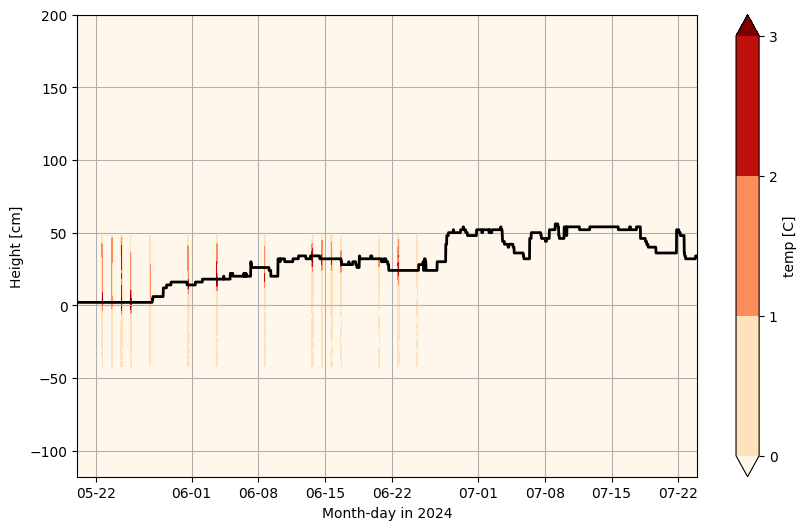

In [232]:
fig, ax = plt.subplots(1, figsize=(10,6))

cb = plt.contourf(simba_dates, simba_depths, np.swapaxes(season_data['shading_correction'][imb_idx,:],0,1), levels=np.arange(0,4,1), 
                  cmap=plt.cm.OrRd, extend='both')
plt.colorbar(cb, label='temp [C]')
plt.plot(simba_dates, multi_adjusted_sfc, c='k', lw=2)
# ax.set_xlim(dt.datetime(2024,6,11),dt.datetime(2024,6,21))
# ax.set_xlim(dt.datetime(2024,5,21),dt.datetime(2024,6,1))

ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
plt.ylabel('Height [cm]')
plt.grid()
# plt.ylim(0,65)
plt.show()

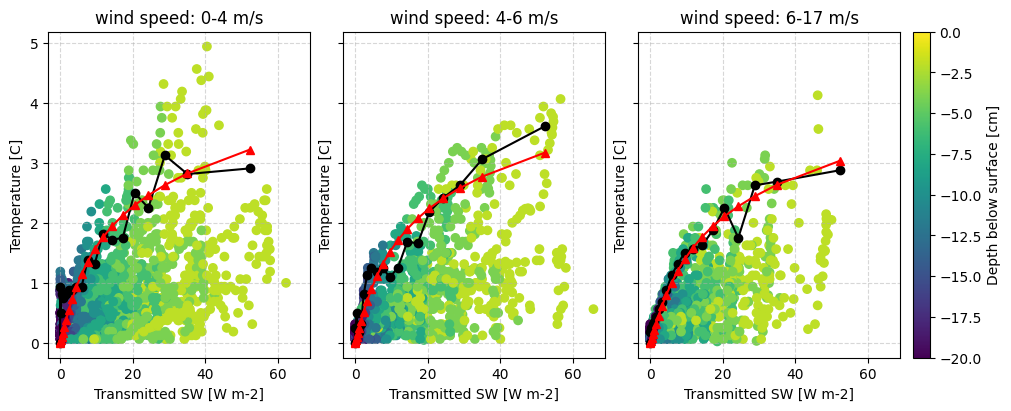

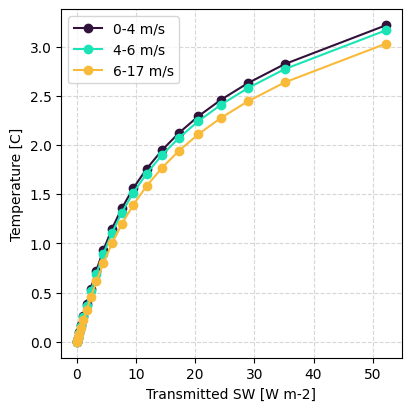

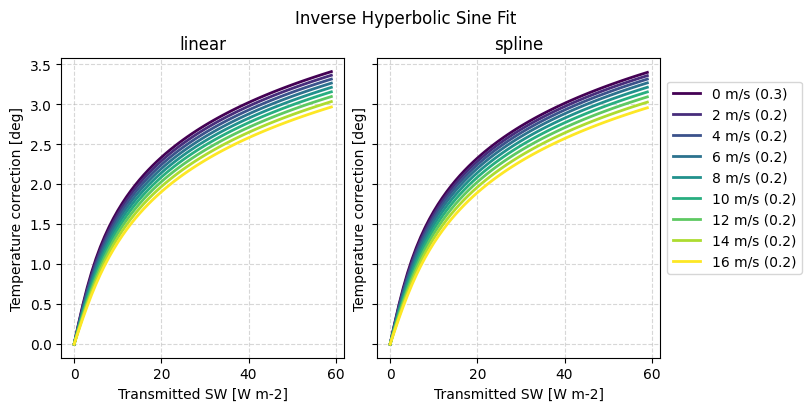

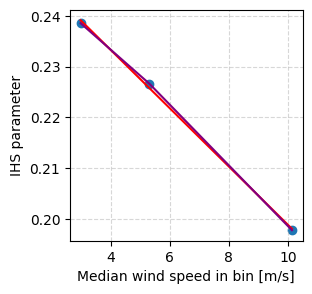

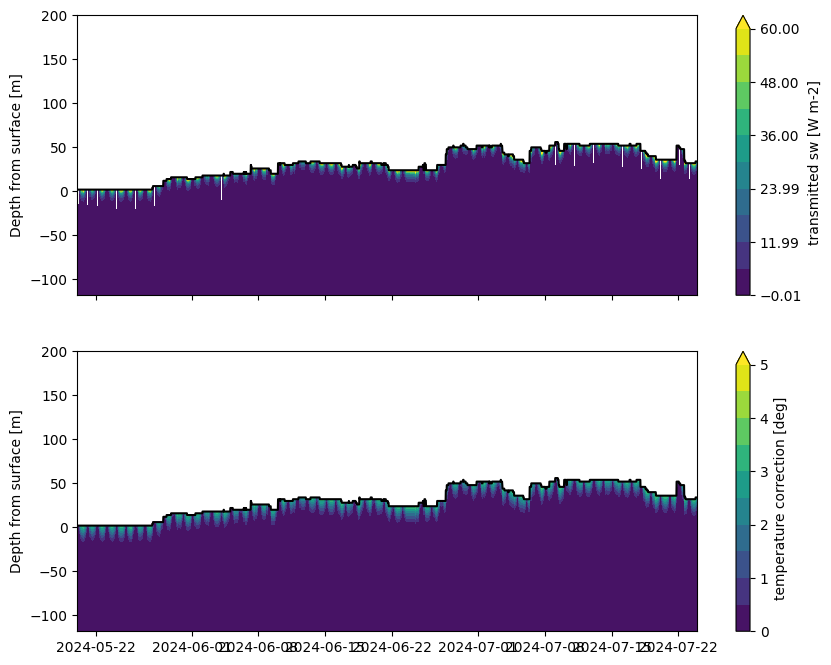

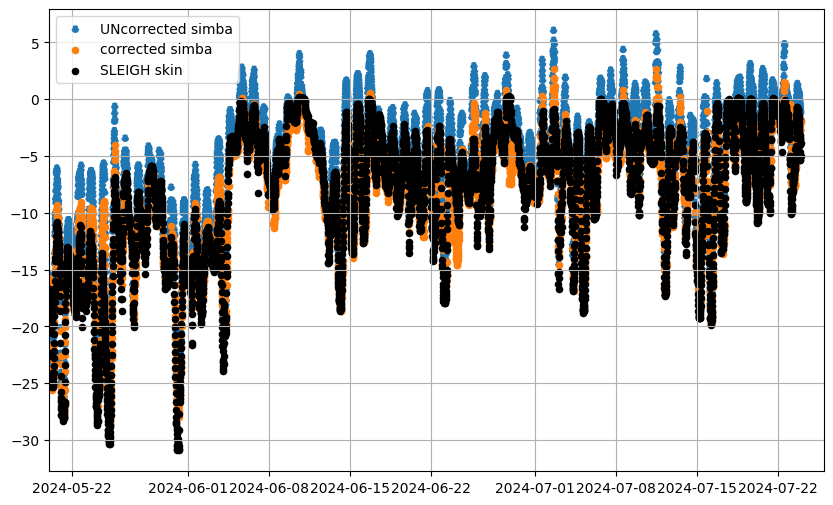

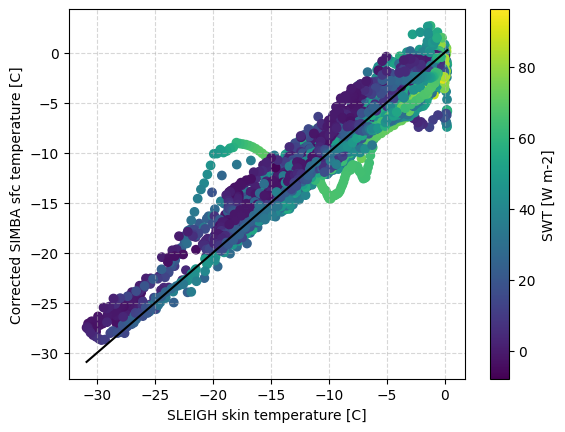

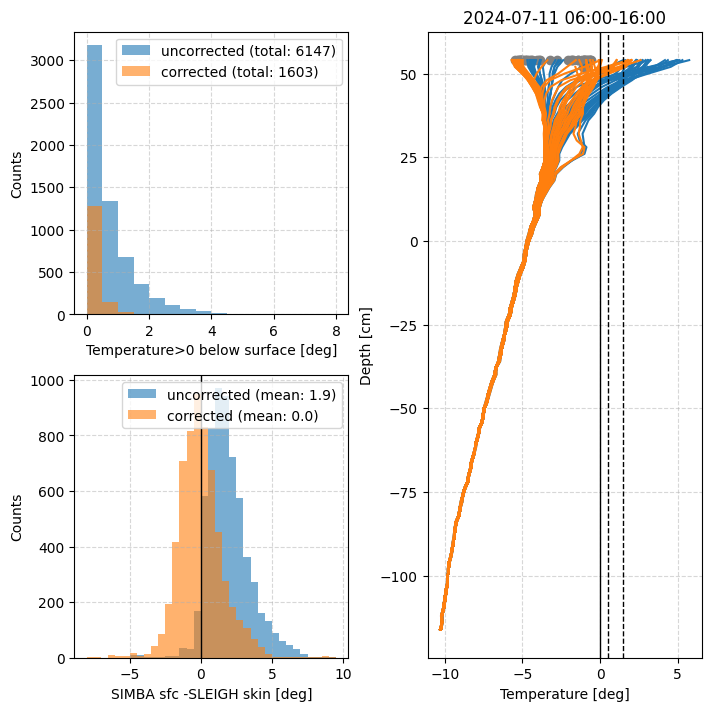

In [233]:
swt_out, wspd_2d_out, simba_skin_2d = get_swt_for_correction(ks_i, fnir_i, 
                                              simba_swn, simba_wspd, simba_skin)

sub_temps_above_out, sub_swabs_above_out, sub_depths_out, sub_wspd_out, all_simba_skin_out = get_subsfc_above_zero_vals(simba_depths, 
                                                                                                    swt_out, wspd_2d_out, 
                                                                                                    simba_sfc, sfc_dif_i, 
                                                                                                    masked_simba_temp, 
                                                                                                    melt_idx_in=False)
sub_depths_out *= -1.

wr = np.percentile(simba_wspd[~simba_wspd.mask], np.arange(0,101,33)) 
# wr = np.percentile(simba_wspd[~simba_wspd.mask], np.arange(0,101,50)) 

# I've only included the functions using an inverse hyperbolic sine (IHS) curve, 
# but it's possible to use other curve if you want to experiment
ihs_params = get_ihs_correction(sub_wspd_out, sub_swabs_above_out, sub_temps_above_out, sub_depths_out, ks_i, 
                                    wind_ranges=wr, plt_figs=True, binval='percentile', p=85)

temp_correction_out, swt_out = calc_temp_corrections(simba_sfc, sfc_dif_i, ks_i, fnir_i, simba_swn, 
                                            simba_depths, ihs_params, simba_wspd, simba_dates, 
                                                     plt_figs=True,  swt=True, param_interp='spline')

corrected_temps_wind = correct_compare_temp(temp_correction_out, simba_sfc, sfc_dif_i, ks_i, fnir_i, 
                                       masked_simba_temp, simba_depths, simba_dates, simba_skin, None, swi=swt_out, )

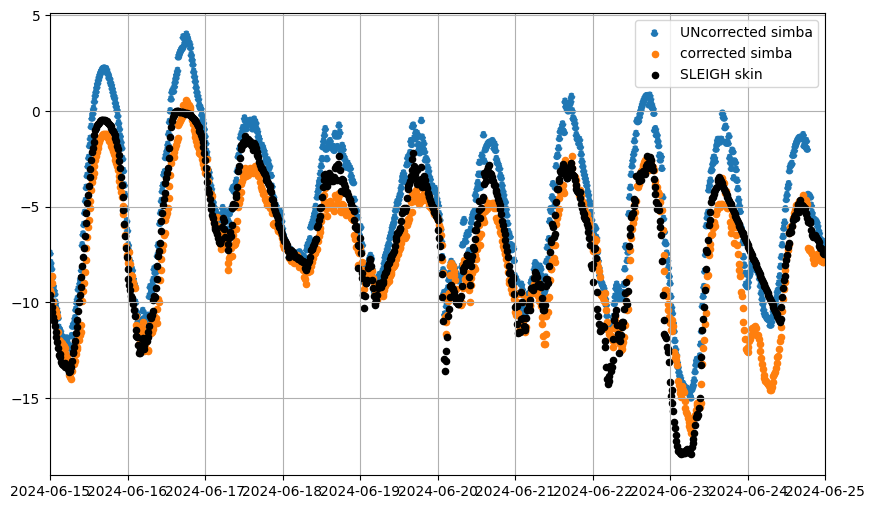

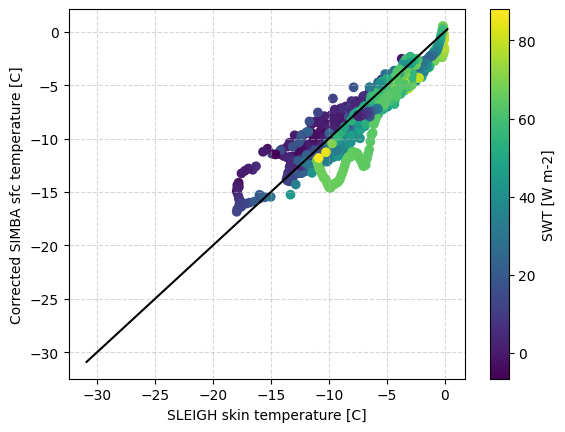

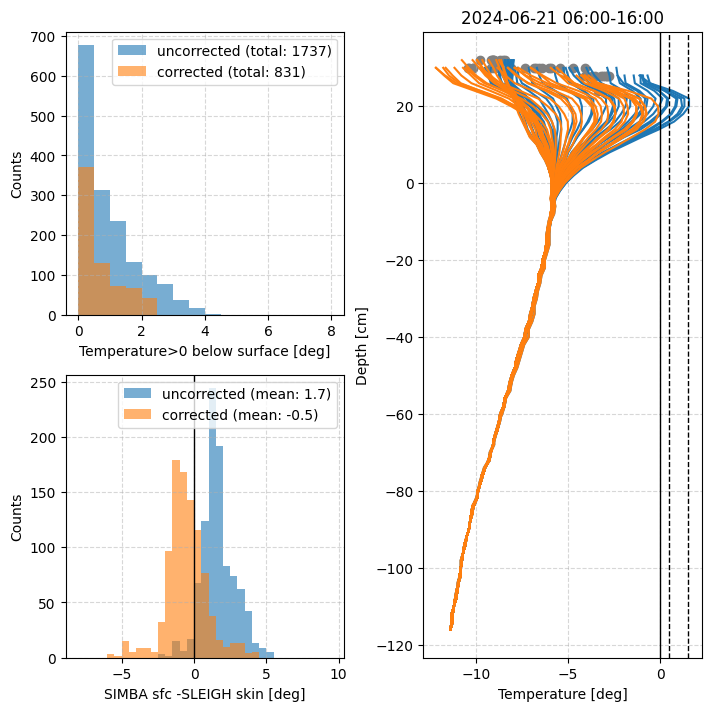

In [224]:
corrected_temps_wind = correct_compare_temp(temp_correction_out, multi_adjusted_sfc, sfc_dif_i, ks_i, fnir_i, 
                                       simba_temps, simba_depths, simba_dates, simba_skin, None, swi=swt_out,
                                       # m=6, d=1, summ_dates=(dt(2024,5,22), dt(2024,6,5)))
                                       # m=5, d=30, summ_dates=(dt.datetime(2024,5,29), dt.datetime(2024,6,11)))
                                       m=6, d=21, summ_dates=(dt.datetime(2024,6,15), dt.datetime(2024,6,25)))

                                       # m=7, d=11, summ_dates=(dt.datetime(2024,7,10), dt.datetime(2024,7,25)))

Saving...

In [235]:
# fn = 'firnprofile_solar-correction_rolling-variance-sfc_created_20250722.nc'
# fn = 'firnprofile_solar-correction_max-daytime-d2Tdz2-sfc_created_20250722.nc'
fn = f'firnprofile_solar-correction_double-splice-v1_sfcdif+{sfc_dif_i}_ksi{ks_i}_created_20250919.nc'

temp_2d_vars = [corrected_temps_wind, season_data['shading_correction'][imb_idx,:], temp_correction_out]
temp_2d_names = ['temp', 'solar_shading_correction', 'solar_heating_correction']

with Dataset(f'/home/asledd/ICECAPS/{fn}', 'w', format='NETCDF4_CLASSIC') as ds:
    # ds.title='SIMBA data from Raven corrected for suspected solar bias. Created in simba_correction_new-sfc.ipynb \
    #             using firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc.\
    #             Extinction coefficent was set to linearly change between 10 and 15 m-1 (ks_i = [10,15]). NIR fraction was 0.5, \
    #             and there was no adjustment to the surface (sfc_dif_i = 0.). Curve fitting was done using the uper 85 percentile of\
    #             SW bins and a functional curve of the form b*(x / (a + x)) for two wind speed bins, 0-4 and 4-25 m/s.\
    #             Surface used was Raven2024_SIMBA_sfc_id_combined-corrected-maxheight_raw-despiked-72h-05threshold_20250416.csv.'
    ds.title=f'SIMBA data from Raven corrected for suspected solar bias. Created in SIMBA_solar_correction_double-splice.ipynb using {simba_fname}. Extinction coefficent was set to  {ks_i} m-1. NIR fraction was {fnir_i}, and with an adjustment to the surface of sfc_dif_i = {sfc_dif_i}cm. Curve fitting was done using the upper 85 percentile of SW bins and an inverse hyperbolic sine fit for three wind speed bins, 0-4, 4-6, and 6-17 m/s. Surface used was {sfc_fname}.'
    
    time = ds.createDimension('time', None)
    times = ds.createVariable('time', np.float64, ('time',))
    times[:] = np.squeeze(simba_seconds)
    times.units = 'seconds since 1970-01-01 00:00'
    times.calendar = 'standard'
    
    depth = ds.createDimension('initial_height', len(simba_depths))
    depths = ds.createVariable('initial_height', np.float64, ('initial_height',))
    depths[:] = simba_depths
    depths.units = 'cm'
    
    for name, data in zip(temp_2d_names, temp_2d_vars):
        value = ds.createVariable(name, np.float64, ('time','initial_height',))
        value.missing_value = -999
        value.units = 'C'
        value[:] = data

    sfc_value = ds.createVariable('detected_surface', np.float64, ('time',))
    sfc_value.missing_value = -999
    sfc_value.units = 'cm'
    sfc_value[:] = simba_sfc+sfc_dif_i


# ds.close()

#### Pickle parameters so that you can just use 

In [52]:
with open('/home/asledd/ICECAPS/Raven_SIMBA_solar-bias-correction_IHS_parameters.pkl', 'wb') as f:
    pickle.dump(ihs_params, f)

Make sure that it worked.

In [53]:
with open('/home/asledd/ICECAPS/Raven_SIMBA_solar-bias-correction_IHS_parameters.pkl', 'rb') as f:
    ihs_params_loaded = pickle.load(f)

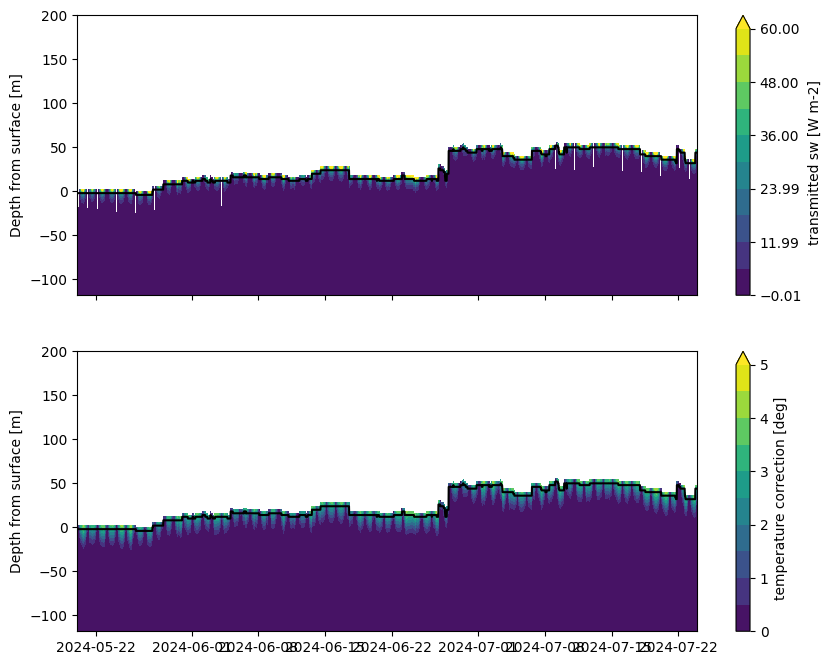

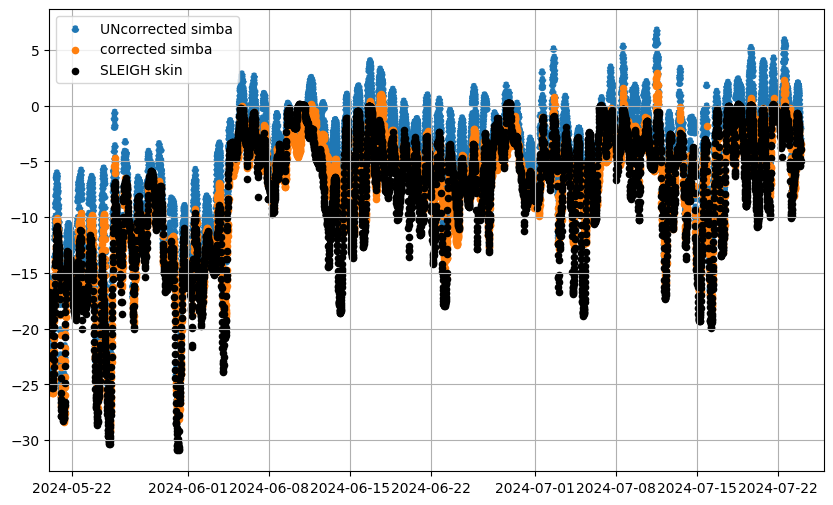

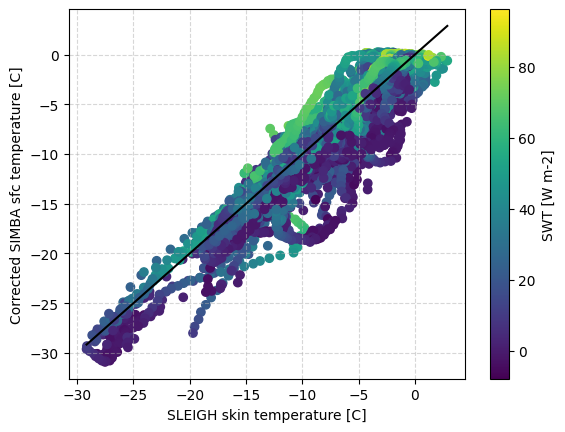

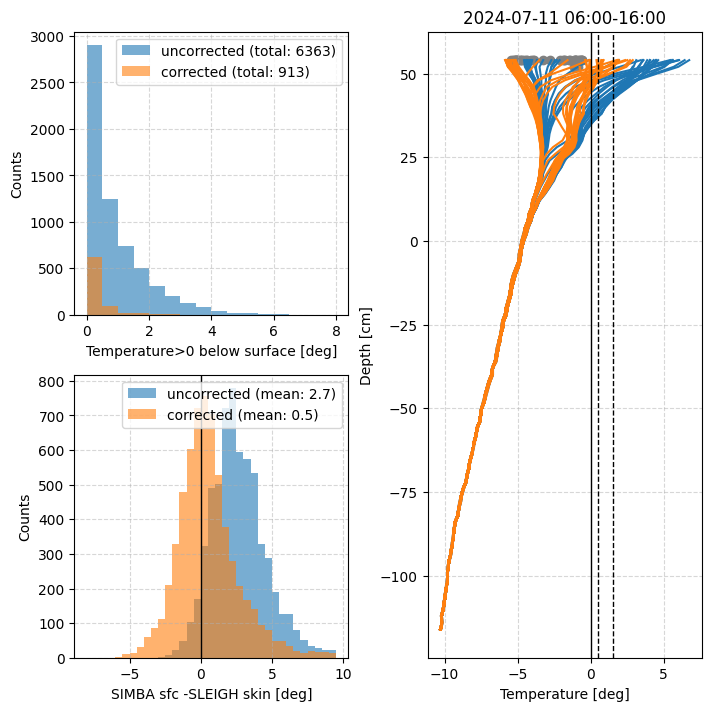

In [54]:
temp_correction_out, swt_out = calc_temp_corrections(simba_sfc, sfc_dif_i, ks_i, fnir_i, simba_swn, 
                                            simba_depths, ihs_params_loaded, simba_wspd, plt_figs=True,  swt=True, param_interp='spline')

corrected_temps_wind = correct_compare_temp(temp_correction_out, simba_sfc, sfc_dif_i, ks_i, fnir_i, 
                                       simba_temps, simba_depths, None, swi=swt_out, )